# Method schematic — glyph plotting toolkit

Small, generator-agnostic plotting helpers for building the **MTS $\to$ SPI $\to$ feature** schematic.
Everything is SPI-general: functions take SPI keys (the `spi_mpis.npz` array names, e.g. `"spearmanr"`)
as a `str` or `list[str]`; per-SPI **label / colour / value-transform / cmap** are resolved from
`meta.json` (overridable via `SPI_CFG`). Channel **grouping** (block-ordering, pair colouring) is
optional and caller-supplied, defaulting to whatever taxonomy the generator recorded.

Assumed data contract (per dataset dir): `timeseries.npy` (T, M), `spi_mpis.npz` (one (M, M) array
per SPI, keyed by SPI name), `meta.json`, and optionally `mother.npy` (the shared latent driver —
present for latent-mother generators; needed only by the mother/filter plots and the selection helpers).

Layout: **one cell per tool = definition + a small usage example**. Figures are intentionally
glyph-scale (thin spines, small fonts); tweak `_FS` / `_LW` / `figsize` per call.

In [77]:
# Presentation-tuned rcParams. Override individually below if needed.
import matplotlib.pyplot as plt
import seaborn as sns

dpi = 500
save_fmt = "svg"   # "png" or "svg"
use_latex = True

sns.set_theme(
    style="white",
    rc={
        "text.usetex": use_latex,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "legend.title_fontsize": 14,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "savefig.transparent": True,
    },
)

In [78]:
import json
from pathlib import Path
import numpy as np
from src.utils import project_root

def load_dataset(dataset_path):
    """Load one dataset dir -> (timeseries (T, M), mpis {spi_name: (M, M)}, meta dict).
    `mpis` is keyed by the raw SPI names in spi_mpis.npz (pass any of these keys to the plotters)."""
    p = Path(dataset_path)
    ts = np.load(p / "timeseries.npy")
    npz = np.load(p / "spi_mpis.npz")
    mpis = {k: npz[k] for k in npz.files}
    meta = json.loads((p / "meta.json").read_text()) if (p / "meta.json").exists() else {}
    return ts, mpis, meta

def load_mother(dataset_path):
    """Shared latent mother z_t (T,) from mother.npy. Latent-mother generators should save it;
    raises if absent (needed only by the mother/filter plots and the signal-strength selectors)."""
    p = Path(dataset_path) / "mother.npy"
    if not p.exists():
        raise FileNotFoundError(f"no mother.npy in {Path(dataset_path)} — save it in the generator")
    return np.load(p)

def channel_groups(meta):
    """Per-channel group labels if the generator recorded a taxonomy (e.g. filter family), else None.
    This is the optional grouping used for block-ordering / pair colouring; override by passing
    `groups=` to any plotter."""
    return (meta.get("generator") or {}).get("types")

In [79]:
# --- Per-SPI display config -------------------------------------------------------------------
# Any SPI key works out of the box: label defaults to the key, colour from a cycle, transform=identity,
# and cmap/range come from meta's pyspi `labels` ("signed" -> diverging RdBu_r/[-1,1], else magma/[0,1]).
# Override per SPI in SPI_CFG (keys = spi_mpis.npz array names). transform: "identity" | "linfoot" | callable.
import itertools

def linfoot(mi_nats):
    """MI (nats) -> Linfoot informational correlation sqrt(1-e^{-2I}) in [0,1] (= |r| for a Gaussian);
    puts an information measure on the correlation scale."""
    return np.sqrt(np.clip(1.0 - np.exp(-2.0 * np.maximum(mi_nats, 0.0)), 0.0, 1.0))

_TRANSFORMS = {"identity": lambda x: x, "linfoot": linfoot}

SPI_CFG = {   # <-- edit for your run's SPIs
    "cov_EmpiricalCovariance": dict(label="$r$"),
    "spearmanr":               dict(label=r"$\rho$"),
    "dcorr":                   dict(label="dCor"),
    "mi_kraskov_NN-4":         dict(label=r"MI$_r$", transform="linfoot"),
}

_SPI_CYCLE = itertools.cycle(["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9"])
_SPI_COLORS = {}

def _spi_signed(spi, meta):
    for s in (meta.get("pyspi") or {}).get("spis", []):
        if s.get("name") == spi:
            return "signed" in s.get("labels", [])
    return None

def spi_cfg(spi, meta=None):
    """Resolve display config for an SPI key -> dict(label, color, transform (callable), cmap, vmin, vmax)."""
    meta = meta or {}
    cfg = dict(SPI_CFG.get(spi, {}))
    tf = cfg.get("transform", "identity")
    transform = _TRANSFORMS[tf] if isinstance(tf, str) else tf
    diverging = bool(_spi_signed(spi, meta)) and tf == "identity"
    return dict(
        label=cfg.get("label", spi),
        color=cfg.get("color") or _SPI_COLORS.setdefault(spi, next(_SPI_CYCLE)),
        transform=transform,
        cmap=cfg.get("cmap", "RdBu_r" if diverging else "magma"),
        vmin=cfg.get("vmin", -1 if diverging else 0),
        vmax=cfg.get("vmax", 1),
    )

def spi_matrix(mpis, spi, meta=None):
    """SPI (M, M) matrix with its configured transform applied."""
    return spi_cfg(spi, meta)["transform"](np.asarray(mpis[spi], float))

In [80]:
# --- glyph style + group colouring ------------------------------------------------------------
_FS = 12         # base fontsize (glyph scale) — bump for standalone figures
_LW = 0.6        # spine / curve line width

def _thin(ax):
    for sp in ax.spines.values(): sp.set_linewidth(_LW)
    ax.tick_params(labelsize=_FS - 1, width=_LW, length=2)

_GROUP_CYCLE = itertools.cycle(["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"])  # Wong
_GROUP_COLORS = {}
def _group_color(g):
    return _GROUP_COLORS.setdefault(g, next(_GROUP_CYCLE))

In [81]:
# --- channel / pair selection (latent-mother generators) --------------------------------------
# Rank by realized signal strength eta^2 = Var(E[x|z]) / Var(x) (correlation ratio), estimated from a
# binned conditional mean — a generator-agnostic SNR proxy that captures monotone AND non-monotone
# dependence on the mother (linear |corr| would read ~0 for an even/non-monotonic filter). Needs mother.npy.
def _signal_strength(ts, mother, bins=24):
    z = np.asarray(mother, float); o = np.argsort(z)
    edges = np.linspace(0, len(z), bins + 1).astype(int)
    out = []
    for i in range(ts.shape[1]):
        x = ts[o, i]; mu = x.mean(); ss = float(((x - mu) ** 2).sum())
        between = sum(len(x[a:b]) * (x[a:b].mean() - mu) ** 2
                      for a, b in zip(edges[:-1], edges[1:]) if b > a)
        out.append(between / ss if ss > 0 else 0.0)
    return np.array(out)

def find_channel(dataset_path, group=None, rank="high"):
    """Channel index, optionally within `group`, by signal strength: rank='high' strongest, 'low'
    weakest, 'median'."""
    ts, _, meta = load_dataset(dataset_path); s = _signal_strength(ts, load_mother(dataset_path))
    groups = channel_groups(meta)
    cand = [i for i in range(ts.shape[1]) if group is None or (groups and groups[i] == group)]
    if not cand: raise ValueError(f"no channel in group={group!r}")
    cand.sort(key=lambda i: s[i])
    return {"high": cand[-1], "low": cand[0], "median": cand[len(cand) // 2]}.get(rank, cand[-1])

def find_pair(dataset_path, group_x=None, group_y=None, rank="high"):
    """Channel pair (i<j). Give both groups to match that pair-type (or neither for any). rank by
    combined signal strength ('high' strongest, 'low' weakest, 'median')."""
    ts, _, meta = load_dataset(dataset_path); s = _signal_strength(ts, load_mother(dataset_path))
    groups = channel_groups(meta); M = ts.shape[1]
    def ok(i, j):
        if group_x is None and group_y is None: return True
        return bool(groups) and {groups[i], groups[j]} == {group_x, group_y}
    cand = [(i, j) for i in range(M) for j in range(i + 1, M) if ok(i, j)]
    if not cand: raise ValueError(f"no pair for groups ({group_x}, {group_y})")
    cand.sort(key=lambda ij: s[ij[0]] + s[ij[1]])
    return {"high": cand[-1], "low": cand[0], "median": cand[len(cand) // 2]}.get(rank, cand[-1])

def scan_channels(dataset_path):
    """Print per-channel group and realized signal strength eta^2 = Var(E[x|z])/Var(x)."""
    ts, _, meta = load_dataset(dataset_path); s = _signal_strength(ts, load_mother(dataset_path))
    groups = channel_groups(meta) or [""] * ts.shape[1]
    print(f"{'ch':>3}  {'group':>16}  {'signal(eta^2)':>13}")
    for i in range(ts.shape[1]):
        print(f"{i:>3}  {str(groups[i]):>16}  {s[i]:>13.3f}")

def scan_channel_pair_spis(dataset_path, spi_a, spi_b, k=8, mode="max", pairtype=None, min_a=None):
    """Rank channel pairs by the gap spi_a - spi_b (both transformed per SPI_CFG) to surface the most
    illustrative pairs. mode='max' largest gap, 'min' most negative. pairtype: restrict to one
    cross/same-group pair-type, e.g. ('linear','monotonic'). min_a: also require spi_a >= min_a.
    Prints a table; returns the rows."""
    _, mpis, meta = load_dataset(dataset_path); groups = channel_groups(meta)
    A, B = spi_matrix(mpis, spi_a, meta), spi_matrix(mpis, spi_b, meta)
    iu = np.triu_indices(A.shape[0], 1); rows = []
    for i, j in zip(*iu):
        pt = tuple(sorted((str(groups[i]), str(groups[j])))) if groups else None
        if pairtype is not None and pt != tuple(sorted(map(str, pairtype))): continue
        a, b = float(A[i, j]), float(B[i, j])
        if min_a is not None and a < min_a: continue
        rows.append((int(i), int(j), pt, a, b, a - b))
    rows.sort(key=lambda r: r[5], reverse=(mode == "max")); rows = rows[:k]
    print(f"{'i':>3} {'j':>3} {'pair':>26} {'a':>7} {'b':>7} {'gap':>7}")
    for i, j, pt, a, b, g in rows:
        print(f"{i:>3} {j:>3} {str(pt):>26} {a:>7.3f} {b:>7.3f} {g:>+7.3f}")
    return rows

## Toy generator — one latent mother, three filter families

A minimal pedagogical MTS: a single **stationary OU / AR(1) latent mother** $z_t$ drives every channel
through a *contemporaneous* filter $g(z)$ plus Gaussian measurement noise (per-channel noise std spread
over a range, so SPI values fan out along their axis rather than collapsing to a point). Three filter
families, chosen so the three SPIs *telescope*:

| family | $g(z)$ | portrait | what the SPIs say |
|---|---|---|---|
| **linear** | $z$ | line | $r\approx\rho\approx\mathrm{dCor}$ high — everyone agrees |
| **monotonic** | $e^{z}$ | monotone curve | $\rho>r$ — rank sees the monotone bend, Pearson sags |
| **non-monotonic** | $z^2$ | arch | $r\approx\rho\approx0$ but $\mathrm{dCor}>0$ — only distance-corr detects it |

plus one **independent-noise** channel (null anchor: every SPI $\approx 0$). This is the vehicle for the
schematic; swap in any generator that writes the same dataset contract. *(A cosine/"sinusoidal" filter
was tried for the non-monotone family but aliases against the wandering mother and dilutes dCor — the
even/odd polynomials give the crisp textbook contrasts.)*

In [82]:
from src.compute import run_pyspi

def latent_ou_mts(M_per=3, T=2000, ar1_a=0.9, noise_lo=0.05, noise_hi=0.35,
                  add_noise_channel=True, seed=0):
    """One stationary AR(1)/OU mother z_t -> channels = contemporaneous filter g(z) + Gaussian noise
    (per-channel std ~ U[noise_lo, noise_hi]). Families: linear (z), monotonic (exp z), non-monotonic
    (z**2), each unit-variance; optional trailing independent-noise channel. Returns (X (T,M), z, types)."""
    rng = np.random.default_rng(seed)
    sd = np.sqrt(1 - ar1_a ** 2); z = np.zeros(T)
    for t in range(1, T):
        z[t] = ar1_a * z[t - 1] + rng.normal(0, sd)
    z = (z - z.mean()) / z.std()
    unit = lambda g: (g - g.mean()) / g.std()
    filters = {"linear": lambda z: z, "monotonic": lambda z: np.exp(z), "non-monotonic": lambda z: z ** 2}
    cols, types = [], []
    for name, g in filters.items():
        base = unit(g(z))
        for _ in range(M_per):
            cols.append(base + rng.normal(0, rng.uniform(noise_lo, noise_hi), T)); types.append(name)
    if add_noise_channel:
        cols.append(rng.standard_normal(T)); types.append("noise")
    return np.column_stack([unit(c) for c in cols]), z, types

def build_dataset(out_dir, config="configs/pyspi-v2/cases/r_rho_mi.yaml", rebuild=False, **gen_kw):
    """Generate one toy MTS, run pyspi (r / rho / MI), and write the dataset contract the toolkit reads:
    timeseries.npy, mother.npy, spi_mpis.npz, meta.json (generator.types grouping + pyspi.spis labels).
    MI (mi_kraskov_NN-4) is stored raw in nats; the toolkit Linfoot-rescales it on the fly via SPI_CFG
    (a monotone bijection -> [0,1] correlation scale, no information lost).
    Skips recompute if the dir already looks complete (unless rebuild=True). Returns the Path.
    NB: `config` is resolved relative to the repo root, so this works from any kernel CWD."""
    out = Path(out_dir)
    if not rebuild and (out / "spi_mpis.npz").exists() and (out / "meta.json").exists():
        return out
    cfg = Path(config)
    if not cfg.is_absolute(): cfg = project_root() / cfg   # anchor to repo root, not the kernel CWD
    out.mkdir(parents=True, exist_ok=True)
    X, z, types = latent_ou_mts(**gen_kw)
    res = run_pyspi(X, config_path=cfg, normalise=False, n_jobs=1)
    np.save(out / "timeseries.npy", X); np.save(out / "mother.npy", z)
    np.savez_compressed(out / "spi_mpis.npz", **res.matrices)
    meta = {"name": out.name, "M": int(X.shape[1]), "T": int(X.shape[0]),
            "generator": {"name": "latent_ou_mts", "types": types},
            "pyspi": {"config": str(config),
                      "spis": [{"name": s.name, "directed": s.directed, "labels": s.labels}
                               for s in res.metadata]}}
    (out / "meta.json").write_text(json.dumps(meta, indent=2))
    return out

In [83]:
# --- build (or reuse) the toy dataset for the usage cells -------------------------------------
# ds = build_dataset(project_root() / "data/schematic/toy_ou", seed=1)   # rebuild=True to regenerate
ds = project_root() / "data/r_rho_mi/260703_g-roll/iter3_LMNM/M32_T2000_I0"
SPIS = list(load_dataset(ds)[1])                       # ['cov_EmpiricalCovariance','spearmanr','dcorr']
ci, cj = find_pair(ds, "linear", "monotonic", "high")  # a monotone-nonlinear pair (rho > r)
print("SPIs:", SPIS, "| example pair:", ci, cj)

SPIs: ['cov_EmpiricalCovariance', 'spearmanr', 'mi_kraskov_NN-4'] | example pair: 6 16


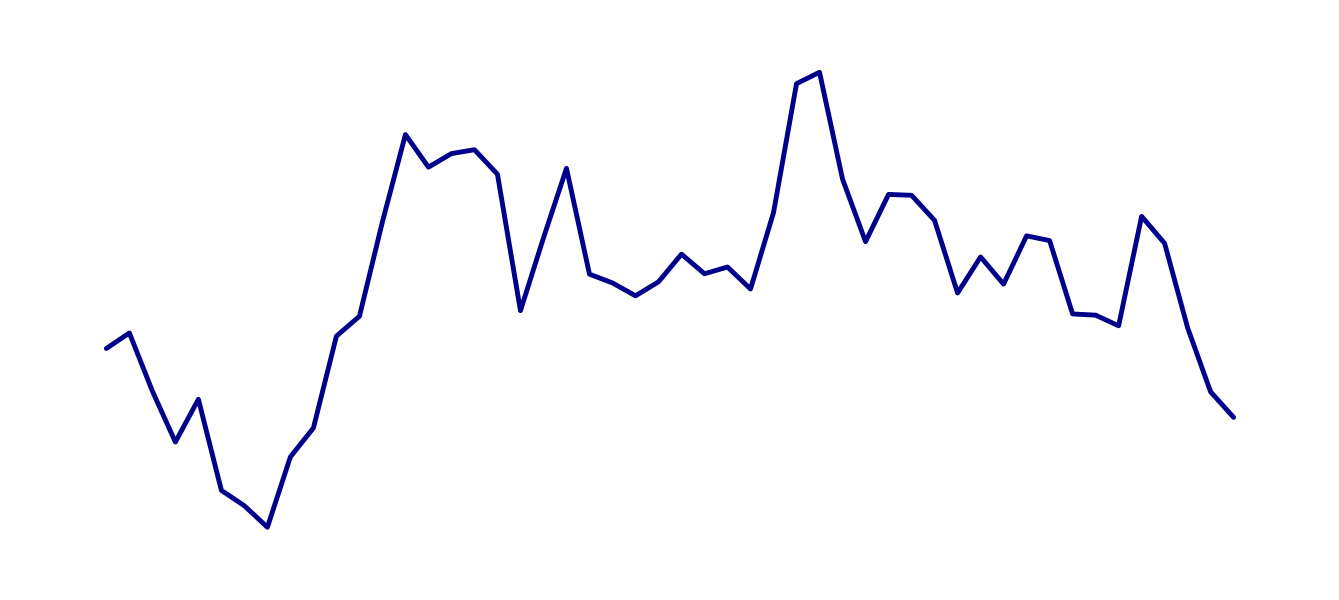

In [84]:
def plot_mother(dataset_path, ax=None, color="#222", t_max=200, lw=0.7):
    """Plot the shared latent mother z_t minimally (no title, no spines). Returns ax."""
    if ax is None: _, ax = plt.subplots(figsize=(3.2, 0.9))
    z = load_mother(dataset_path)
    ax.plot(z[:t_max], color=color, lw=lw)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    return ax

fig, ax = plt.subplots(figsize=(3.2, 1.3), dpi=500)
plot_mother(ds, color="darkblue", t_max=50, ax=ax)
fig.patch.set_alpha(0); plt.show()
# fig.savefig("mother.svg", bbox_inches="tight", transparent=True)   # uncomment to save

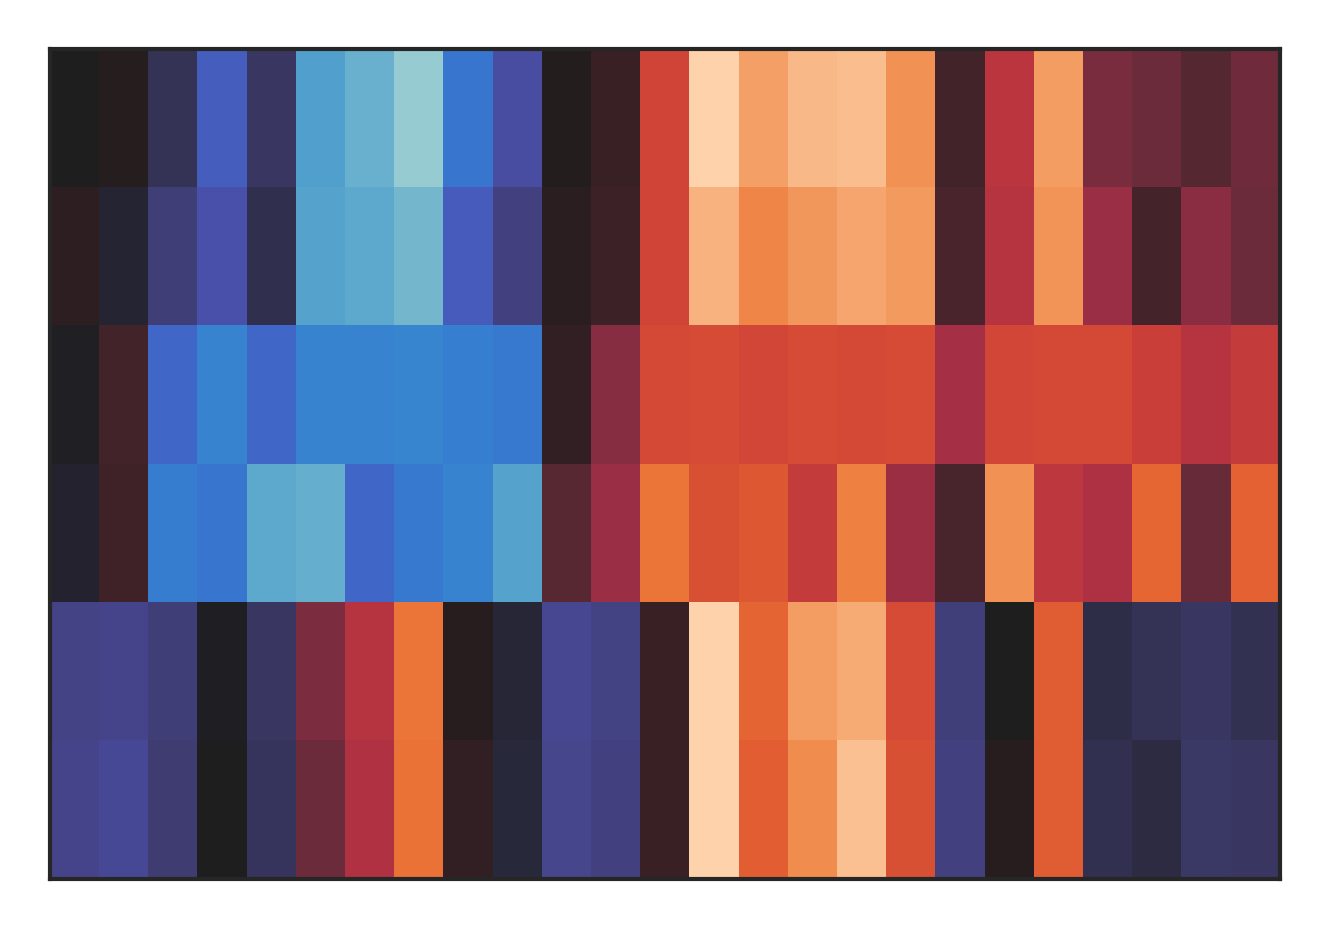

In [88]:
def plot_mts_heatmap(dataset_path, ax=None, channels=None, groups=None, t_max=None,
                     order_by_group=True, randomize=False, cmap="RdBu_r", vlim=2):
    """MTS as a bare channels x time heatmap. channels: explicit subset/order (overrides grouping).
    Else, if a grouping is available and order_by_group, channels are sorted into group blocks.
    t_max crops time; vlim sets the symmetric (z-scored) colour range. Returns ax."""
    ts, _, meta = load_dataset(dataset_path)
    if groups is None: groups = channel_groups(meta)
    if channels is not None:
        order = np.asarray(channels)
    elif groups is not None and order_by_group:
        uniq = list(dict.fromkeys(groups))
        order = np.argsort([uniq.index(g) for g in groups], kind="stable")
    elif randomize and channels is not None:
        order = np.arange(ts.shape[1]); np.random.shuffle(order)
    else:
        order = np.arange(ts.shape[1])
    X = ts[:t_max, order].T                              # (channels, time)
    if ax is None: _, ax = plt.subplots(figsize=(3.2, 2.2))
    ax.imshow(X, aspect="auto", cmap=cmap, vmin=-vlim, vmax=vlim)
    ax.set_xticks([]); ax.set_yticks([]); _thin(ax); return ax

# a subset for legibility (any indices, any order); e.g. via find_channel:
sel = [find_channel(ds, g, r) for g in ("linear", "monotonic", "non-monotonic")
       for r in ("high", "low")]
fig, ax = plt.subplots(figsize=(3, 2.2), dpi=500)
plot_mts_heatmap(ds, ax=ax, channels=sel, order_by_group=False, randomize=True, cmap="icefire", t_max=25)   # channels=None -> all (grouped)
fig.tight_layout(); plt.show()
# fig.savefig("mts_heatmap.svg", bbox_inches="tight")   # uncomment to save

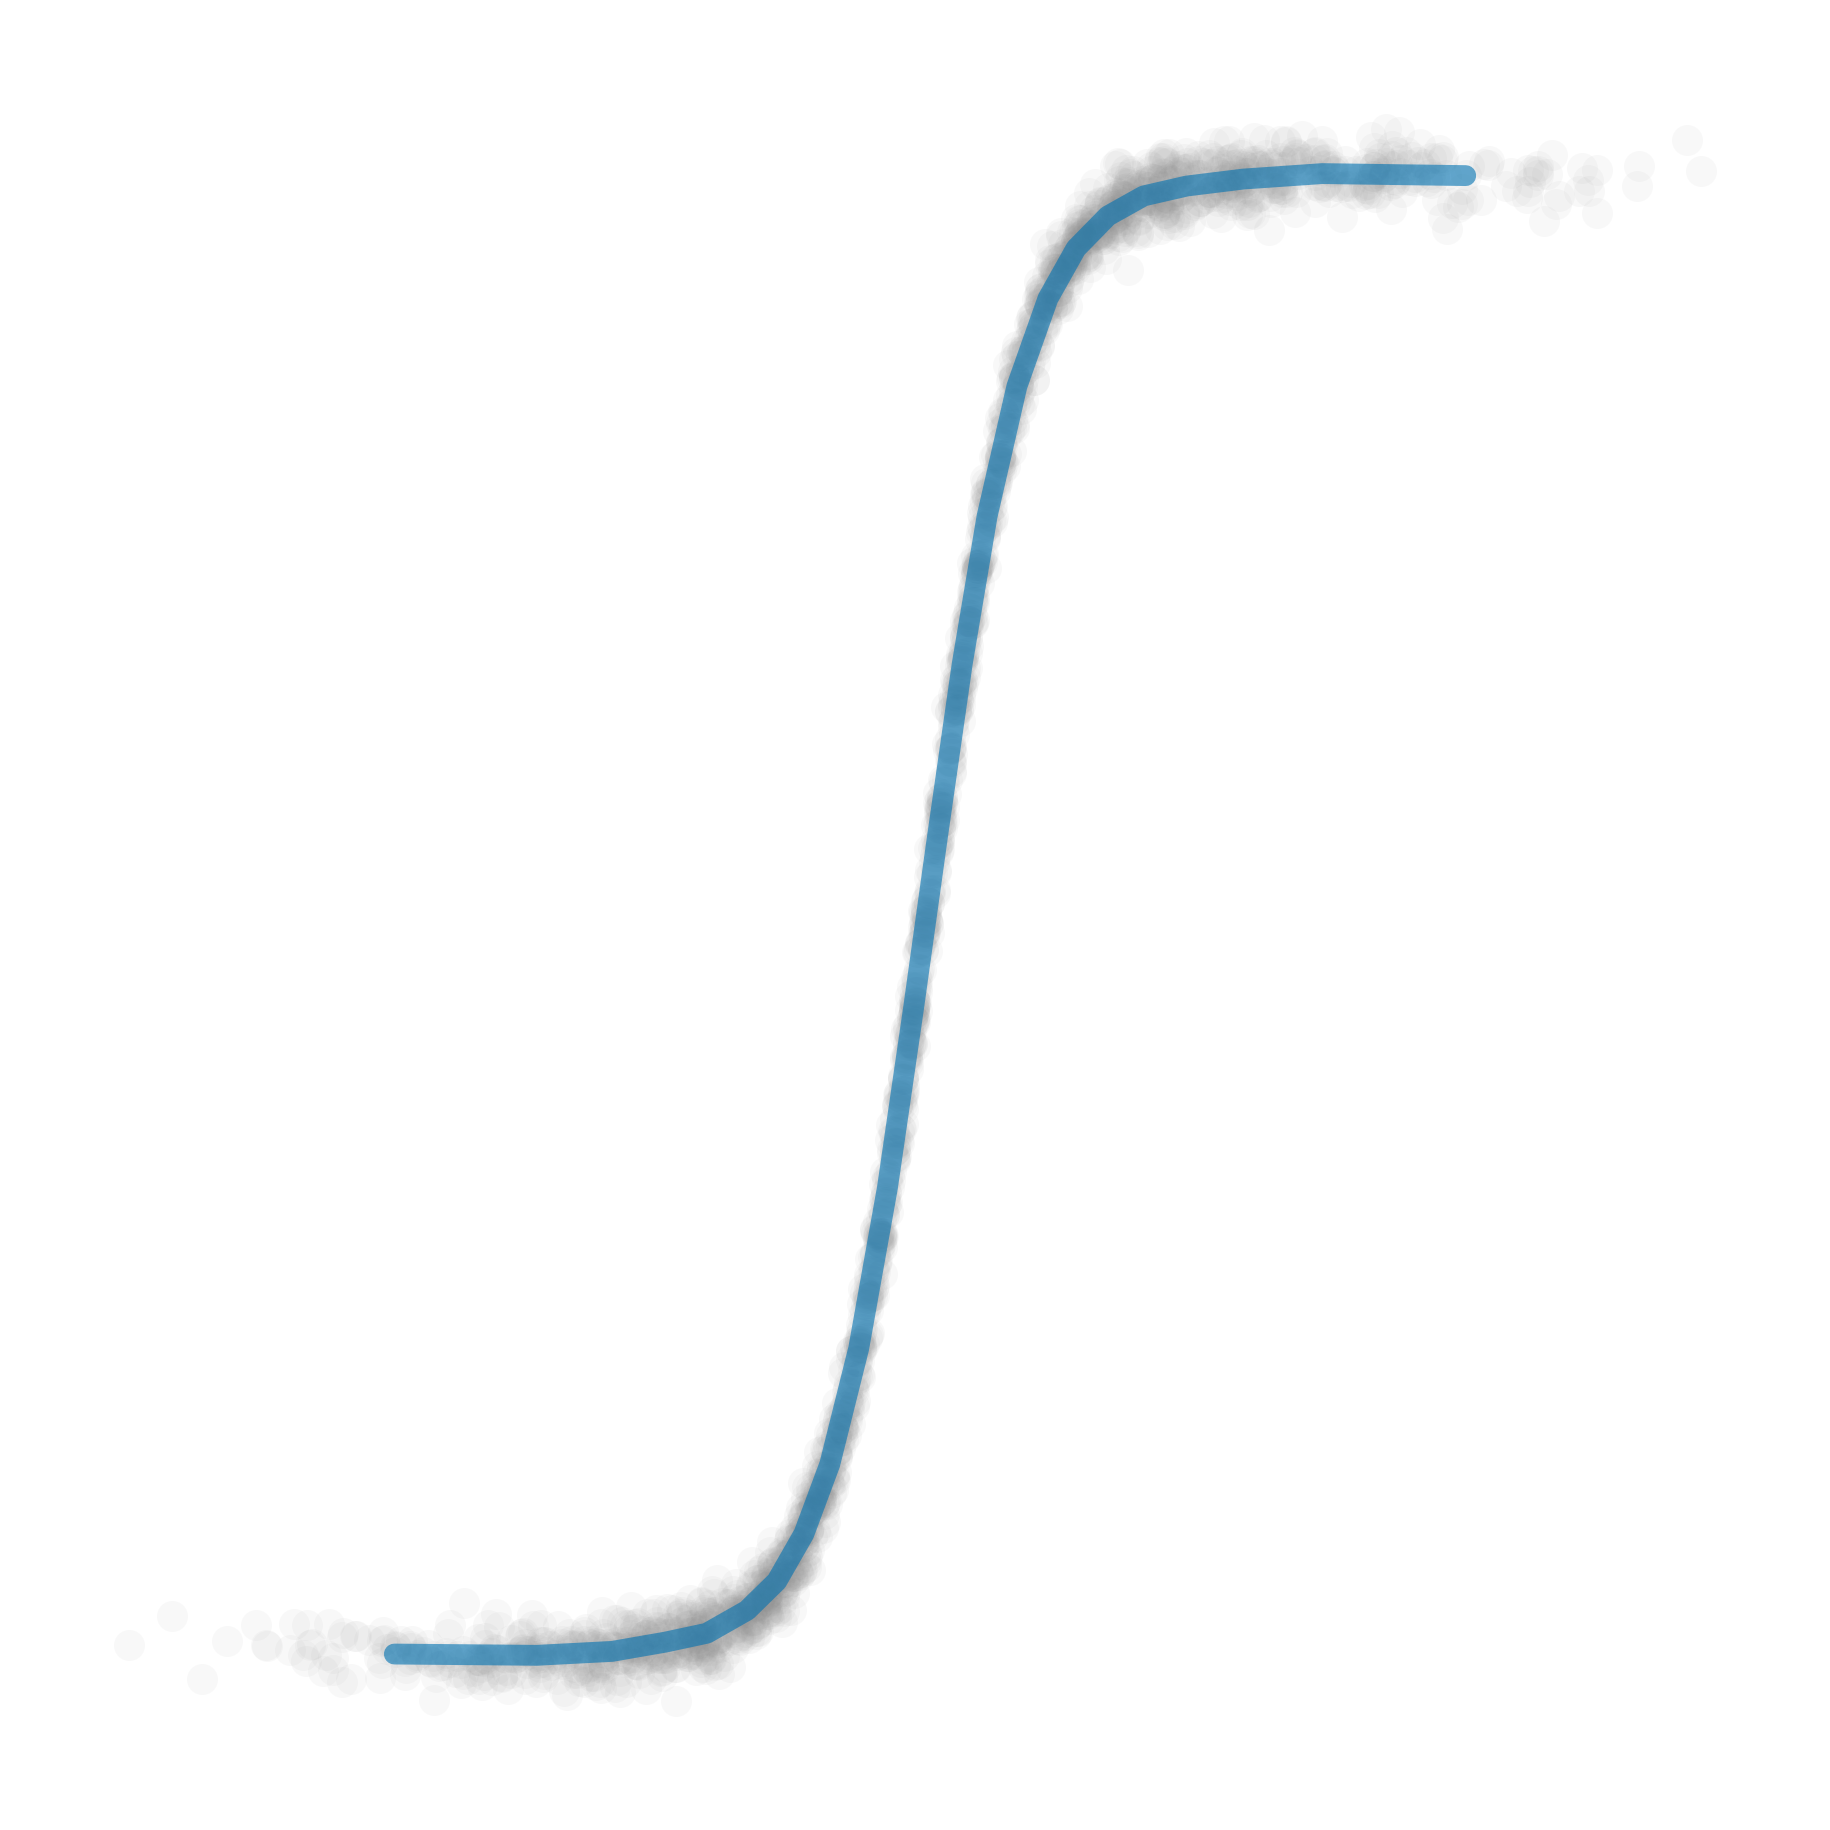

In [86]:
def _conditional_mean(z, x, bins=24):
    """Nonparametric filter estimate: mean of x within equal-count bins of z. Returns (z_c, x_c).
    Works for any (monotone or not) transfer function without knowing its analytic form."""
    o = np.argsort(z); z, x = np.asarray(z)[o], np.asarray(x)[o]
    edges = np.linspace(0, len(z), bins + 1).astype(int)
    zc = [z[a:b].mean() for a, b in zip(edges[:-1], edges[1:]) if b > a]
    xc = [x[a:b].mean() for a, b in zip(edges[:-1], edges[1:]) if b > a]
    return np.array(zc), np.array(xc)

def plot_filter_function(dataset_path, channel, ax=None, s=4, point_alpha=0.2, line_alpha=0.9,
                         lw=1.4, color=None, bins=24):
    """Scatter (mother z_t, channel x_t) with the channel's realized transfer function g(z) overlaid
    as a binned conditional mean — for any latent-mother generator. Returns ax."""
    if ax is None: _, ax = plt.subplots(figsize=(2.2, 2.2))
    ts, _, meta = load_dataset(dataset_path); z = load_mother(dataset_path)
    x = ts[:, channel]; groups = channel_groups(meta)
    col = color or (_group_color(groups[channel]) if groups else "#8c564b")
    ax.scatter(z, x, s=s, alpha=point_alpha, color="gray", linewidths=0)
    zc, xc = _conditional_mean(z, x, bins)
    ax.plot(zc, xc, color=col, alpha=line_alpha, lw=lw)
    ax.set_xticks([]); ax.set_yticks([]); _thin(ax); ax.set_box_aspect(1)
    for sp in ax.spines.values(): sp.set_visible(False)
    return ax

fig, ax = plt.subplots(figsize=(5, 4), dpi=500)
plot_filter_function(ds, cj, s=20, point_alpha=0.05, line_alpha=0.6, lw=3, ax=ax)
fig.patch.set_alpha(0); ax.patch.set_alpha(0); fig.tight_layout(); plt.show()
# fig.savefig(f"filter_ch{cj}.svg", bbox_inches="tight")   # uncomment to save

In [87]:
def plot_pair_phase(dataset_path, channel_x, channel_y, ax=None, s=4, alpha=0.2,
                    color="#34495e", centered=False):
    """Phase portrait of channel_x vs channel_y. centered=True -> spines through 0, no box. Returns ax."""
    if ax is None: _, ax = plt.subplots(figsize=(2.2, 2.2))
    ts, _, _ = load_dataset(dataset_path)
    ax.scatter(ts[:, channel_x], ts[:, channel_y], s=s, alpha=alpha, color=color, linewidths=0)
    ax.set_xlabel(rf"$X[{channel_x}]$", fontsize=_FS); ax.set_ylabel(rf"$X[{channel_y}]$", fontsize=_FS)
    ax.set_xticks([]); ax.set_yticks([]); _thin(ax); ax.set_box_aspect(1)
    if centered:                                        # comment out to keep the frame
        for sd in ("left", "bottom"): ax.spines[sd].set_position("zero")
        for sd in ("top", "right"): ax.spines[sd].set_visible(False)
    return ax

fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=500)
plot_pair_phase(ds, ci, cj, s=5, color="navy", alpha=0.1, centered=False, ax=ax)
fig.patch.set_alpha(0); 
fig.tight_layout(); 
plt.show()
# fig.savefig(f"phase_{ci}_{cj}.svg", bbox_inches="tight")   # uncomment to save

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmr12.tfm' in your texmf tree, but could not find it

Error in callback <function _draw_all_if_interactive at 0x1136f9bc0> (for post_execute), with arguments args (),kwargs {}:


FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmr12.tfm' in your texmf tree, but could not find it

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmr12.tfm' in your texmf tree, but could not find it

<Figure size 1250x1250 with 1 Axes>

In [ ]:
def plot_pair_spis(dataset_path, channel_x, channel_y, spis=None, ax=None, y_label=None):
    """Bar of the given SPIs for one channel pair, coloured/labelled/transformed per SPI_CFG (e.g. MI
    shown Linfoot-rescaled). spis: list of spi_mpis.npz keys (default: all SPIs present). Returns ax."""
    _, mpis, meta = load_dataset(dataset_path)
    if spis is None: spis = list(mpis)
    if ax is None: _, ax = plt.subplots(figsize=(2.2, 2.2))
    labs, vals, cols = [], [], []
    for spi in spis:
        cfg = spi_cfg(spi, meta)
        vals.append(float(spi_matrix(mpis, spi, meta)[channel_x, channel_y]))
        labs.append(cfg["label"]); cols.append(cfg["color"])
    bars = ax.bar(labs, vals, width=0.7, color=cols)
    ax.axhline(0, color="grey", lw=0.5)
    for b, v in zip(bars, vals):                          # value labels (comment out to drop)
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=_FS - 6)
    ax.grid(True, axis="y", alpha=0.3)
    if y_label is not None: ax.set_ylabel(y_label, fontsize=_FS)
    ax.set_ylim(min(0, min(vals)) - 0.05, (max(vals) * 1.15 if max(vals) > 0 else 1.05))
    _thin(ax)
    for sp in ("top", "right", "left"): ax.spines[sp].set_visible(False)
    return ax

fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=500)
plot_pair_spis(ds, ci, cj, spis=SPIS, ax=ax)
fig.patch.set_alpha(0); fig.tight_layout(); plt.show()
# fig.savefig(f"spis_{ci}_{cj}.svg", bbox_inches="tight")   # uncomment to save

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmr10.tfm' in your texmf tree, but could not find it

Error in callback <function _draw_all_if_interactive at 0x1136f9bc0> (for post_execute), with arguments args (),kwargs {}:


FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmr10.tfm' in your texmf tree, but could not find it

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmr10.tfm' in your texmf tree, but could not find it

<Figure size 1600x1400 with 1 Axes>

In [ ]:
def plot_pair_phase_spis(dataset_path, channel_x, channel_y, spis=None,
                         figsize=(4.4, 2.2), width_ratios=(1.4, 1), axes=None, **phase_kw):
    """Composite: phase portrait (left) + SPI bars (right) for one pair. **phase_kw -> plot_pair_phase.
    Returns (fig, (ax_phase, ax_bars))."""
    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": width_ratios})
    else:
        fig = axes[0].figure
    plot_pair_phase(dataset_path, channel_x, channel_y, ax=axes[0], **phase_kw)
    plot_pair_spis(dataset_path, channel_x, channel_y, spis=spis, ax=axes[1])
    fig.tight_layout()
    return fig, axes

fig, axes = plot_pair_phase_spis(ds, ci, cj, spis=SPIS, s=5, color="navy", alpha=0.1)
fig.patch.set_alpha(0); plt.show()
# fig.savefig(f"phase_spis_{ci}_{cj}.svg", bbox_inches="tight")   # uncomment to save

In [ ]:
def plot_mpi_heatmap(dataset_path, spi, ax=None, groups=None, mask_diag=True, dividers=True, cmap=None):
    """Single-SPI MPI heatmap. If a grouping is available (or passed), channels are sorted into group
    blocks with dividers + block tick labels. cmap/range default from the SPI's config (signed ->
    RdBu_r/[-1,1], else magma/[0,1]); override via cmap. Returns ax."""
    _, mpis, meta = load_dataset(dataset_path)
    if groups is None: groups = channel_groups(meta)
    Mm = spi_matrix(mpis, spi, meta); n = Mm.shape[0]
    if groups is not None:
        uniq = list(dict.fromkeys(groups))
        order = np.argsort([uniq.index(g) for g in groups], kind="stable")
    else:
        order = np.arange(n)
    Mre = Mm[np.ix_(order, order)].astype(float)
    if mask_diag: np.fill_diagonal(Mre, np.nan)
    cfg = spi_cfg(spi, meta)
    if ax is None: _, ax = plt.subplots(figsize=(2.7, 2.7))
    im = ax.imshow(Mre, cmap=cmap or cfg["cmap"], vmin=cfg["vmin"], vmax=cfg["vmax"])
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(cfg["label"], fontsize=_FS)
    if groups is not None:
        g_ord = [groups[k] for k in order]
        blocks = {g: [k for k, gg in enumerate(g_ord) if gg == g] for g in uniq}
        if dividers:
            for idx in list(blocks.values())[:-1]:
                ax.axhline(idx[-1] + 0.5, color="w", lw=0.5); ax.axvline(idx[-1] + 0.5, color="w", lw=0.5)
        tk = [np.mean(idx) for idx in blocks.values()]
        ax.set_xticks(tk); ax.set_yticks(tk)
        ax.set_xticklabels(blocks.keys(), fontsize=_FS - 1, rotation=90)
        ax.set_yticklabels(blocks.keys(), fontsize=_FS - 1)
    else:
        ax.set_xticks([]); ax.set_yticks([])
    _thin(ax); return ax

fig, ax = plt.subplots(figsize=(2.7, 2.7))
plot_mpi_heatmap(ds, SPIS[-1], ax=ax)              # try any key in SPIS
fig.tight_layout(); plt.show()
# fig.savefig("mpi.svg", bbox_inches="tight")   # uncomment to save

In [ ]:
def plot_spi_plane(dataset_path, spi_x, spi_y, ax=None, groups=None, annotate=True):
    """Scatter every channel pair in the (spi_x, spi_y) plane (each transformed per SPI_CFG). If a
    grouping is available, same-group pairs are grey and each cross-group pair-type gets a colour;
    annotate f = corr(spi_x, spi_y) over all pairs (the meta-feature). Returns ax."""
    _, mpis, meta = load_dataset(dataset_path)
    if groups is None: groups = channel_groups(meta)
    xv = spi_matrix(mpis, spi_x, meta); yv = spi_matrix(mpis, spi_y, meta)
    iu = np.triu_indices(xv.shape[0], 1); xv, yv = xv[iu], yv[iu]
    if ax is None: _, ax = plt.subplots(figsize=(2.4, 2.4))
    if groups is not None:
        labs = np.array(["-".join(sorted((str(groups[i]), str(groups[j])))) for i, j in zip(*iu)])
        same = np.array([str(groups[i]) == str(groups[j]) for i, j in zip(*iu)])
        ax.scatter(xv[same], yv[same], s=8, facecolors="none", edgecolors="#bbb", linewidths=0.5, alpha=0.7)
        for lab in sorted(set(labs[~same])):
            m = labs == lab
            ax.scatter(xv[m], yv[m], s=10, alpha=0.35, color=_group_color(lab), label=lab)
    else:
        ax.scatter(xv, yv, s=10, alpha=0.35, color="#34495e", linewidths=0)
    if annotate:
        f = float(np.corrcoef(xv, yv)[0, 1])
        ax.text(0.04, 0.96, f"$f$={f:+.2f}", transform=ax.transAxes, va="top", fontsize=_FS - 1,
                bbox=dict(boxstyle="round", fc="white", ec="magenta", lw=0.4, alpha=0.85))
    ax.set_xlabel(spi_cfg(spi_x, meta)["label"], fontsize=_FS)
    ax.set_ylabel(spi_cfg(spi_y, meta)["label"], fontsize=_FS)
    ax.set_box_aspect(1); _thin(ax); return ax

fig, ax = plt.subplots(figsize=(4, 4))
plot_spi_plane(ds, SPIS[1], SPIS[-1], ax=ax)       # e.g. (rho, MI)
fig.patch.set_alpha(0); fig.tight_layout(); plt.legend(fontsize=7); plt.show()
# fig.savefig("plane.svg", bbox_inches="tight")   # uncomment to save